# ChemAI

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from chembl_webresource_client.new_client import new_client

from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
pd.set_option('display.max_columns', 120)

/Users/mvl/code/mephi/unsupervised_learning/.venv/lib/python3.13/site-packages/chembl_webresource_client/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __version__ = __import__('pkg_resources').get_distribution('chembl_webresource_client').version


## 1. Kaggle data и baseline

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sample_submission.csv')

In [3]:
target_columns = ['IC50, mM', 'CC50, mM', 'SI']

X = train.drop(columns=target_columns)
y = train[target_columns]

imputer = SimpleImputer(strategy='median')

X_imputed = imputer.fit_transform(X)
test_imputed = imputer.transform(test)

X = pd.DataFrame(X_imputed, columns=X.columns)
test = pd.DataFrame(test_imputed, columns=test.columns)

In [4]:
target_columns = ['IC50, mM', 'CC50, mM', 'SI']
submission_columns = ['IC50', 'CC50', 'SI']

feature_columns = [
    col for col in train.columns
    if col not in target_columns + ['index']
]

X_raw = X[feature_columns].copy()
X_test_raw = test[feature_columns].copy()
y_raw = y[target_columns].copy()

print('Train:', train.shape)
print('Test:', test.shape)
print('Features:', len(feature_columns))

Train: (751, 214)
Test: (250, 211)
Features: 210


In [5]:
limits = {
    'IC50, mM': (0, 20000),
    'CC50, mM': (0, 20000),
    'SI':       (0, 250),
}

y_clipped = y_raw.copy()
y_clipped[list(limits)] = y_clipped[list(limits)].clip(
    lower={k: v[0] for k, v in limits.items()},
    upper={k: v[1] for k, v in limits.items()}
)

imputer_full = SimpleImputer(strategy='median')

X = pd.DataFrame(
    imputer_full.fit_transform(X_raw),
    columns=feature_columns
)

X_test = pd.DataFrame(
    imputer_full.transform(X_test_raw),
    columns=feature_columns
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y_clipped,
    test_size=0.2,
    random_state=RANDOM_STATE
)

baseline_model = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

baseline_model.fit(X_train, y_train)
valid_pred = baseline_model.predict(X_valid)

print('Baseline validation scores:')
for i, target in enumerate(target_columns):
    mae = mean_absolute_error(y_valid.iloc[:, i], valid_pred[:, i])
    rmse = mean_squared_error(y_valid.iloc[:, i], valid_pred[:, i]) ** 0.5
    r2 = r2_score(y_valid.iloc[:, i], valid_pred[:, i])
    print(f'{target}: MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}')

baseline_model.fit(X, y_clipped)
baseline_pred = baseline_model.predict(X_test)

baseline_submission = sample_submission.copy()
baseline_submission[submission_columns] = baseline_pred


baseline_submission.to_csv('submission_baseline_clipped.csv', index=False)
print('Saved submission_baseline_clipped.csv')

Baseline validation scores:
IC50, mM: MAE=190.2928, RMSE=388.3364, R2=0.1823
CC50, mM: MAE=283.7714, RMSE=429.9894, R2=0.4413
SI: MAE=18.2231, RMSE=34.0035, R2=0.3623
Saved submission_baseline_clipped.csv


## 2. Загрузка ChEMBL
target_ids взяты с https://www.ebi.ac.uk/ по фильтру "organism=Influenza"

In [6]:
target = new_client.target
activity = new_client.activity

target_ids = [
    'CHEMBL355',
    'CHEMBL613740',
    'CHEMBL613128',
    'CHEMBL612783',
    'CHEMBL613129',
    'CHEMBL2366902',
    'CHEMBL2367089',
    'CHEMBL612610',
]

activity_fields = [
    'activity_id',
    'molecule_chembl_id',
    'canonical_smiles',
    'standard_type',
    'standard_relation',
    'standard_value',
    'standard_units',
    'pchembl_value',
    'assay_chembl_id',
    'target_chembl_id',
    'document_chembl_id'
]

In [7]:
# 1. Загружаем информацию по target
target_info_rows = []

for target_id in target_ids:
    try:
        info = target.get(target_id)
        target_info_rows.append({
            'target_chembl_id': info.get('target_chembl_id'),
            'pref_name': info.get('pref_name'),
            'organism': info.get('organism'),
            'target_type': info.get('target_type'),
            'tax_id': info.get('tax_id'),
        })
    except Exception as e:
        print('Target error:', target_id, e)

targets_df = pd.DataFrame(target_info_rows)

print('Targets:')
display(targets_df)

Targets:


,target_chembl_id,pref_name,organism,target_type,tax_id
0,CHEMBL355,Haemophilus influenzae,Haemophilus influenzae,ORGANISM,727
1,CHEMBL613740,Influenza A virus,Influenza A virus,ORGANISM,11320
2,CHEMBL613128,unidentified influenza virus,unidentified influenza virus,ORGANISM,11309
3,CHEMBL612783,Influenza C virus,Influenza C virus,ORGANISM,11552
4,CHEMBL613129,Influenza B virus,Influenza B virus,ORGANISM,11520
5,CHEMBL2366902,Influenza A virus H3N2,Influenza A virus H3N2,ORGANISM,41857
6,CHEMBL2367089,Influenza A virus (H1N1),Influenza A virus (H1N1),ORGANISM,1323429
7,CHEMBL612610,Influenza A virus (A/Puerto Rico/8/1934(H1N1)),Influenza A virus (A/Puerto Rico/8/1934(H1N1)),ORGANISM,211044


In [9]:
# 2. Загружаем активности по всем target
activity_rows = []

for i, target_id in enumerate(target_ids):
    print(f'Loading {i + 1}/{len(target_ids)}: {target_id}')
    
    try:
        acts = activity.filter(
            target_chembl_id=target_id
        ).only(activity_fields)
        
        temp = pd.DataFrame(list(acts))
        
        if len(temp) > 0:
            temp['source_target_chembl_id'] = target_id
            activity_rows.append(temp)
            print('  rows:', len(temp))
        else:
            print('  no activities')
            
    except Exception as e:
        print('  Activity error:', target_id, e)

acts_df = pd.concat(activity_rows, ignore_index=True)

print('All activities shape:', acts_df.shape)
display(acts_df.head())

Loading 1/8: CHEMBL355
  rows: 9028
Loading 2/8: CHEMBL613740
  rows: 12937
Loading 3/8: CHEMBL613128
  rows: 292
Loading 4/8: CHEMBL612783
  rows: 3
Loading 5/8: CHEMBL613129
  rows: 2208
Loading 6/8: CHEMBL2366902
  rows: 594
Loading 7/8: CHEMBL2367089
  rows: 17
Loading 8/8: CHEMBL612610
  rows: 103
All activities shape: (25182, 16)


,activity_id,assay_chembl_id,canonical_smiles,document_chembl_id,molecule_chembl_id,pchembl_value,relation,standard_relation,standard_type,standard_units,standard_value,target_chembl_id,type,units,value,source_target_chembl_id
0,32654,CHEMBL688186,Cc1cccc2c(CN(C)C(=O)/C=C/c3cnc4c(c3)CCC(=O)N4)...,CHEMBL1136775,CHEMBL46425,None,>,>,MIC50,ug.mL-1,64.0,CHEMBL355,MIC50,ug ml-1,64.0,CHEMBL355
1,34020,CHEMBL857202,COC1/C=C/OC2(C)Oc3c(C)c(O)c4c(O)c(c5scnc5c4c3C...,CHEMBL1124774,CHEMBL407311,None,=,=,MIC,ug.mL-1,0.125,CHEMBL355,MIC,ug ml-1,0.125,CHEMBL355
2,34114,CHEMBL857202,COC1/C=C/OC2(C)Oc3c(C)c(O)c4c(O)c(c5sc(N6CCN(c...,CHEMBL1124774,CHEMBL285521,None,=,=,MIC,ug.mL-1,0.125,CHEMBL355,MIC,ug ml-1,0.125,CHEMBL355
3,36501,CHEMBL857202,CCNc1nc2c(s1)c1c(O)c3c(O)c(C)c4c(c32)C(=O)C(C)...,CHEMBL1124774,CHEMBL416220,None,=,=,MIC,ug.mL-1,0.125,CHEMBL355,MIC,ug ml-1,0.125,CHEMBL355
4,38781,CHEMBL688186,CN(Cc1cc2ccccc2n1C)C(=O)/C=C/c1ccc(N)nc1,CHEMBL1136775,CHEMBL297053,None,>,>,MIC50,ug.mL-1,64.0,CHEMBL355,MIC50,ug ml-1,64.0,CHEMBL355


In [10]:
# 3. Добавляем organism / target name к активностям
acts_df = acts_df.merge(
    targets_df,
    on='target_chembl_id',
    how='left'
)

# Удаляем дубли, если одна и та же activity попала через разные target
acts_df = acts_df.drop_duplicates()

print(acts_df.shape)
display(acts_df.head())

display(acts_df['organism'].value_counts(dropna=False))
display(acts_df['standard_type'].value_counts().head(40))
display(acts_df['standard_units'].value_counts(dropna=False))

(25182, 20)


,activity_id,assay_chembl_id,canonical_smiles,document_chembl_id,molecule_chembl_id,pchembl_value,relation,standard_relation,standard_type,standard_units,standard_value,target_chembl_id,type,units,value,source_target_chembl_id,pref_name,organism,target_type,tax_id
0,32654,CHEMBL688186,Cc1cccc2c(CN(C)C(=O)/C=C/c3cnc4c(c3)CCC(=O)N4)...,CHEMBL1136775,CHEMBL46425,None,>,>,MIC50,ug.mL-1,64.0,CHEMBL355,MIC50,ug ml-1,64.0,CHEMBL355,Haemophilus influenzae,Haemophilus influenzae,ORGANISM,727
1,34020,CHEMBL857202,COC1/C=C/OC2(C)Oc3c(C)c(O)c4c(O)c(c5scnc5c4c3C...,CHEMBL1124774,CHEMBL407311,None,=,=,MIC,ug.mL-1,0.125,CHEMBL355,MIC,ug ml-1,0.125,CHEMBL355,Haemophilus influenzae,Haemophilus influenzae,ORGANISM,727
2,34114,CHEMBL857202,COC1/C=C/OC2(C)Oc3c(C)c(O)c4c(O)c(c5sc(N6CCN(c...,CHEMBL1124774,CHEMBL285521,None,=,=,MIC,ug.mL-1,0.125,CHEMBL355,MIC,ug ml-1,0.125,CHEMBL355,Haemophilus influenzae,Haemophilus influenzae,ORGANISM,727
3,36501,CHEMBL857202,CCNc1nc2c(s1)c1c(O)c3c(O)c(C)c4c(c32)C(=O)C(C)...,CHEMBL1124774,CHEMBL416220,None,=,=,MIC,ug.mL-1,0.125,CHEMBL355,MIC,ug ml-1,0.125,CHEMBL355,Haemophilus influenzae,Haemophilus influenzae,ORGANISM,727
4,38781,CHEMBL688186,CN(Cc1cc2ccccc2n1C)C(=O)/C=C/c1ccc(N)nc1,CHEMBL1136775,CHEMBL297053,None,>,>,MIC50,ug.mL-1,64.0,CHEMBL355,MIC50,ug ml-1,64.0,CHEMBL355,Haemophilus influenzae,Haemophilus influenzae,ORGANISM,727


organism
Influenza A virus                                 12937
Haemophilus influenzae                             9028
Influenza B virus                                  2208
Influenza A virus H3N2                              594
unidentified influenza virus                        292
Influenza A virus (A/Puerto Rico/8/1934(H1N1))      103
Influenza A virus (H1N1)                             17
Influenza C virus                                     3
Name: count, dtype: int64

standard_type
MIC                  6923
EC50                 6281
Activity             3870
IC50                 3656
Inhibition           1449
MIC90                 588
MIC50                 512
Ratio                 199
Ratio IC50            193
EC90                  176
Survival              171
MBC                   163
FC                    130
ED50                  118
CC50                   87
Selectivity ratio      69
Ratio EC50             67
IC90                   65
log10cfu               63
log10FFU               48
TIME                   46
EC99                   24
IZ                     23
MED                    22
PDD50                  21
PAE                    18
PFU                    13
PD50                   13
Reduction              11
log10 TCID50            9
log10PFU/ml             9
MIC50/MIC90             8
MBC50                   8
MIC=>80                 8
TCID50                  8
MBC90                   7
GI                      7
CI                      

standard_units
nM             8811
ug.mL-1        8773
NaN            4547
%              2346
uM              278
ug ml-1         236
hr               65
mm               21
mM               18
HAU/ml           18
mg.kg-1          17
mg kg-1          14
day              13
log10FFU/ml      12
log10PFU/ml       3
min               2
degrees C         2
ug                1
ng.hr.mL-1        1
log10CFU          1
U                 1
10^5PFU/g         1
mg/kg/day         1
Name: count, dtype: int64

In [11]:
ic50_df = acts_df[
    acts_df['standard_type'] == 'IC50'
].copy()

ic50_df['standard_value'] = pd.to_numeric(
    ic50_df['standard_value'],
    errors='coerce'
)

ic50_df = ic50_df.dropna(subset=['standard_value'])

# Оставляем точные значения
ic50_df = ic50_df[
    ic50_df['standard_relation'].isna() |
    (ic50_df['standard_relation'] == '=')
].copy()

# Оставляем нормальные концентрационные единицы
ic50_df = ic50_df[
    ic50_df['standard_units'].isin(['nM', 'uM', 'µM', 'mM'])
].copy()

print(ic50_df.shape)
display(ic50_df.head())
display(ic50_df['standard_units'].value_counts())
display(ic50_df['organism'].value_counts())

(2456, 20)


,activity_id,assay_chembl_id,canonical_smiles,document_chembl_id,molecule_chembl_id,pchembl_value,relation,standard_relation,standard_type,standard_units,standard_value,target_chembl_id,type,units,value,source_target_chembl_id,pref_name,organism,target_type,tax_id
9037,76866,CHEMBL808323,CC(=O)Nc1ccc(C(=O)O)cc1NC(=O)CO,CHEMBL1128587,CHEMBL327097,NaN,=,=,IC50,nM,4000000.0,CHEMBL613740,IC50,mM,4.0,CHEMBL613740,Influenza A virus,Influenza A virus,ORGANISM,11320
9039,77906,CHEMBL808323,CC(=O)Nc1c(O)cc(C(=O)O)cc1[N+](=O)[O-],CHEMBL1128587,CHEMBL324455,NaN,=,=,IC50,nM,750000.0,CHEMBL613740,IC50,mM,0.75,CHEMBL613740,Influenza A virus,Influenza A virus,ORGANISM,11320
9040,77908,CHEMBL808324,CC(=O)Nc1c(O)cc(C(=O)O)cc1[N+](=O)[O-],CHEMBL1128587,CHEMBL324455,NaN,=,=,IC50,nM,1000000.0,CHEMBL613740,IC50,mM,1.0,CHEMBL613740,Influenza A virus,Influenza A virus,ORGANISM,11320
9041,79067,CHEMBL808323,CC(=O)Nc1c(OC(C)=O)cc(C(=O)O)cc1[N+](=O)[O-],CHEMBL1128587,CHEMBL321393,NaN,=,=,IC50,nM,5000000.0,CHEMBL613740,IC50,mM,5.0,CHEMBL613740,Influenza A virus,Influenza A virus,ORGANISM,11320
9042,79069,CHEMBL808324,CC(=O)Nc1c(OC(C)=O)cc(C(=O)O)cc1[N+](=O)[O-],CHEMBL1128587,CHEMBL321393,NaN,=,=,IC50,nM,3000000.0,CHEMBL613740,IC50,mM,3.0,CHEMBL613740,Influenza A virus,Influenza A virus,ORGANISM,11320


standard_units
nM    2456
Name: count, dtype: int64

organism
Influenza A virus                                 2211
Influenza B virus                                  116
Influenza A virus H3N2                              54
unidentified influenza virus                        41
Influenza A virus (A/Puerto Rico/8/1934(H1N1))      33
Influenza C virus                                    1
Name: count, dtype: int64

In [12]:
acts_df.to_csv('chembl_multiple_influenza_targets_activities.csv', index=False)
ic50_df.to_csv('chembl_multiple_influenza_targets_ic50.csv', index=False)

print('Saved files')

Saved files


## 3. Оставляем IC50 и добавляем assay descriptions

In [13]:
chembl_ic50_long = acts_df[
    acts_df['standard_type'].eq('IC50')
].copy()

chembl_ic50_long['standard_value'] = pd.to_numeric(
    chembl_ic50_long['standard_value'],
    errors='coerce'
)

chembl_ic50_long = chembl_ic50_long.dropna(
    subset=['standard_value', 'canonical_smiles', 'assay_chembl_id']
)

print('IC50 rows:', chembl_ic50_long.shape)
display(chembl_ic50_long['standard_units'].value_counts())
display(chembl_ic50_long.head())

IC50 rows: (3463, 20)


standard_units
nM         2930
ug.mL-1     533
Name: count, dtype: int64

,activity_id,assay_chembl_id,canonical_smiles,document_chembl_id,molecule_chembl_id,pchembl_value,relation,standard_relation,standard_type,standard_units,standard_value,target_chembl_id,type,units,value,source_target_chembl_id,pref_name,organism,target_type,tax_id
9037,76866,CHEMBL808323,CC(=O)Nc1ccc(C(=O)O)cc1NC(=O)CO,CHEMBL1128587,CHEMBL327097,NaN,=,=,IC50,nM,4000000.0,CHEMBL613740,IC50,mM,4.0,CHEMBL613740,Influenza A virus,Influenza A virus,ORGANISM,11320
9038,76868,CHEMBL808324,CC(=O)Nc1ccc(C(=O)O)cc1NC(=O)CO,CHEMBL1128587,CHEMBL327097,NaN,>,>,IC50,nM,10000000.0,CHEMBL613740,IC50,mM,10.0,CHEMBL613740,Influenza A virus,Influenza A virus,ORGANISM,11320
9039,77906,CHEMBL808323,CC(=O)Nc1c(O)cc(C(=O)O)cc1[N+](=O)[O-],CHEMBL1128587,CHEMBL324455,NaN,=,=,IC50,nM,750000.0,CHEMBL613740,IC50,mM,0.75,CHEMBL613740,Influenza A virus,Influenza A virus,ORGANISM,11320
9040,77908,CHEMBL808324,CC(=O)Nc1c(O)cc(C(=O)O)cc1[N+](=O)[O-],CHEMBL1128587,CHEMBL324455,NaN,=,=,IC50,nM,1000000.0,CHEMBL613740,IC50,mM,1.0,CHEMBL613740,Influenza A virus,Influenza A virus,ORGANISM,11320
9041,79067,CHEMBL808323,CC(=O)Nc1c(OC(C)=O)cc(C(=O)O)cc1[N+](=O)[O-],CHEMBL1128587,CHEMBL321393,NaN,=,=,IC50,nM,5000000.0,CHEMBL613740,IC50,mM,5.0,CHEMBL613740,Influenza A virus,Influenza A virus,ORGANISM,11320


In [14]:
assay = new_client.assay

assay_ids = chembl_ic50_long['assay_chembl_id'].dropna().unique().tolist()
assay_rows = []

for assay_id in assay_ids:
    try:
        item = assay.get(assay_id)
        assay_rows.append({
            'assay_chembl_id': assay_id,
            'description': item.get('description'),
            'assay_type': item.get('assay_type'),
            'target_chembl_id_assay': item.get('target_chembl_id'),
            'document_chembl_id_assay': item.get('document_chembl_id')
        })
    except Exception as e:
        print('Error:', assay_id, e)

assays_df = pd.DataFrame(assay_rows)

chembl_ic50_long = chembl_ic50_long.merge(
    assays_df,
    on='assay_chembl_id',
    how='left'
)

print(chembl_ic50_long.shape)
display(chembl_ic50_long.head())

(3463, 24)


,activity_id,assay_chembl_id,canonical_smiles,document_chembl_id,molecule_chembl_id,pchembl_value,relation,standard_relation,standard_type,standard_units,standard_value,target_chembl_id,type,units,value,source_target_chembl_id,pref_name,organism,target_type,tax_id,description,assay_type,target_chembl_id_assay,document_chembl_id_assay
0,76866,CHEMBL808323,CC(=O)Nc1ccc(C(=O)O)cc1NC(=O)CO,CHEMBL1128587,CHEMBL327097,NaN,=,=,IC50,nM,4000000.0,CHEMBL613740,IC50,mM,4.0,CHEMBL613740,Influenza A virus,Influenza A virus,ORGANISM,11320,The compound was tested in vitro for the inhib...,F,CHEMBL613740,CHEMBL1128587
1,76868,CHEMBL808324,CC(=O)Nc1ccc(C(=O)O)cc1NC(=O)CO,CHEMBL1128587,CHEMBL327097,NaN,>,>,IC50,nM,10000000.0,CHEMBL613740,IC50,mM,10.0,CHEMBL613740,Influenza A virus,Influenza A virus,ORGANISM,11320,The compound was tested in vitro for the inhib...,F,CHEMBL613740,CHEMBL1128587
2,77906,CHEMBL808323,CC(=O)Nc1c(O)cc(C(=O)O)cc1[N+](=O)[O-],CHEMBL1128587,CHEMBL324455,NaN,=,=,IC50,nM,750000.0,CHEMBL613740,IC50,mM,0.75,CHEMBL613740,Influenza A virus,Influenza A virus,ORGANISM,11320,The compound was tested in vitro for the inhib...,F,CHEMBL613740,CHEMBL1128587
3,77908,CHEMBL808324,CC(=O)Nc1c(O)cc(C(=O)O)cc1[N+](=O)[O-],CHEMBL1128587,CHEMBL324455,NaN,=,=,IC50,nM,1000000.0,CHEMBL613740,IC50,mM,1.0,CHEMBL613740,Influenza A virus,Influenza A virus,ORGANISM,11320,The compound was tested in vitro for the inhib...,F,CHEMBL613740,CHEMBL1128587
4,79067,CHEMBL808323,CC(=O)Nc1c(OC(C)=O)cc(C(=O)O)cc1[N+](=O)[O-],CHEMBL1128587,CHEMBL321393,NaN,=,=,IC50,nM,5000000.0,CHEMBL613740,IC50,mM,5.0,CHEMBL613740,Influenza A virus,Influenza A virus,ORGANISM,11320,The compound was tested in vitro for the inhib...,F,CHEMBL613740,CHEMBL1128587


## 4. Единицы измерения

In [15]:
def convert_ic50_units(value, units):
    if pd.isna(value):
        return pd.Series({'IC50_nM': np.nan, 'IC50_uM': np.nan, 'IC50_mM': np.nan})

    if units == 'nM':
        return pd.Series({
            'IC50_nM': value,
            'IC50_uM': value / 1000,
            'IC50_mM': value / 1_000_000
        })

    if units in ['uM', 'µM', 'umol/L']:
        return pd.Series({
            'IC50_nM': value * 1000,
            'IC50_uM': value,
            'IC50_mM': value / 1000
        })

    if units == 'mM':
        return pd.Series({
            'IC50_nM': value * 1_000_000,
            'IC50_uM': value * 1000,
            'IC50_mM': value
        })

    return pd.Series({'IC50_nM': np.nan, 'IC50_uM': np.nan, 'IC50_mM': np.nan})

unit_values = chembl_ic50_long.apply(
    lambda row: convert_ic50_units(row['standard_value'], row['standard_units']),
    axis=1
)

chembl_ic50_long = pd.concat(
    [chembl_ic50_long.reset_index(drop=True), unit_values.reset_index(drop=True)],
    axis=1
)

chembl_ic50_long = chembl_ic50_long[
    chembl_ic50_long['IC50_uM'].notna() &
    (chembl_ic50_long['IC50_uM'] > 0)
].copy()

print('Rows with molar IC50:', chembl_ic50_long.shape)
display(chembl_ic50_long[['standard_value', 'standard_units', 'IC50_nM', 'IC50_uM', 'IC50_mM']].head())
display(chembl_ic50_long['standard_units'].value_counts())

Rows with molar IC50: (2930, 27)


,standard_value,standard_units,IC50_nM,IC50_uM,IC50_mM
0,4000000.0,nM,4000000.0,4000.0,4.00
1,10000000.0,nM,10000000.0,10000.0,10.00
2,750000.0,nM,750000.0,750.0,0.75
3,1000000.0,nM,1000000.0,1000.0,1.00
4,5000000.0,nM,5000000.0,5000.0,5.00


standard_units
nM    2930
Name: count, dtype: int64

In [16]:
display(chembl_ic50_long[['standard_value', 'standard_units', 'IC50_nM', 'IC50_uM', 'IC50_mM']].describe())

,standard_value,IC50_nM,IC50_uM,IC50_mM
count,2.930000e+03,2.930000e+03,2930.000000,2.930000e+03
mean,1.900112e+05,1.900112e+05,190.011209,1.900112e-01
std,1.409783e+06,1.409783e+06,1409.782849,1.409783e+00
min,9.000000e-03,9.000000e-03,0.000009,9.000000e-09
25%,3.400000e+02,3.400000e+02,0.340000,3.400000e-04
50%,7.000000e+03,7.000000e+03,7.000000,7.000000e-03
75%,3.332250e+04,3.332250e+04,33.322500,3.332250e-02
max,5.000000e+07,5.000000e+07,50000.000000,5.000000e+01


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Kaggle IC50
kaggle_ic50 = train['IC50, mM'].dropna()
kaggle_ic50 = kaggle_ic50[kaggle_ic50 > 0]

chembl_ic50_units = chembl_ic50_long[
    (chembl_ic50_long['standard_type'] == 'IC50')
    & (chembl_ic50_long['standard_value'].notna())
    & (chembl_ic50_long['standard_value'] > 0)
    & (chembl_ic50_long['standard_value'] < 5000000)  # <------------------ тут можно фильтровать standard_value по верхнему порогу
].copy()

# Переводим ChEMBL в разные шкалы
chembl_ic50_units['IC50_nM'] = np.nan
chembl_ic50_units['IC50_uM'] = np.nan
chembl_ic50_units['IC50_mM'] = np.nan

mask_nm = chembl_ic50_units['standard_units'] == 'nM'
mask_um = chembl_ic50_units['standard_units'].isin(['uM', 'µM', 'umol/L'])
mask_mm = chembl_ic50_units['standard_units'] == 'mM'

# Если исходно nM
chembl_ic50_units.loc[mask_nm, 'IC50_nM'] = chembl_ic50_units.loc[mask_nm, 'standard_value']
chembl_ic50_units.loc[mask_nm, 'IC50_uM'] = chembl_ic50_units.loc[mask_nm, 'standard_value'] / 1000
chembl_ic50_units.loc[mask_nm, 'IC50_mM'] = chembl_ic50_units.loc[mask_nm, 'standard_value'] / 1_000_000

# Если исходно uM
chembl_ic50_units.loc[mask_um, 'IC50_nM'] = chembl_ic50_units.loc[mask_um, 'standard_value'] * 1000
chembl_ic50_units.loc[mask_um, 'IC50_uM'] = chembl_ic50_units.loc[mask_um, 'standard_value']
chembl_ic50_units.loc[mask_um, 'IC50_mM'] = chembl_ic50_units.loc[mask_um, 'standard_value'] / 1000

# Если исходно mM
chembl_ic50_units.loc[mask_mm, 'IC50_nM'] = chembl_ic50_units.loc[mask_mm, 'standard_value'] * 1_000_000
chembl_ic50_units.loc[mask_mm, 'IC50_uM'] = chembl_ic50_units.loc[mask_mm, 'standard_value'] * 1000
chembl_ic50_units.loc[mask_mm, 'IC50_mM'] = chembl_ic50_units.loc[mask_mm, 'standard_value']

# Убираем пустые значения
chembl_nM = chembl_ic50_units['IC50_nM'].dropna()
chembl_uM = chembl_ic50_units['IC50_uM'].dropna()
chembl_mM = chembl_ic50_units['IC50_mM'].dropna()

chembl_nM = chembl_nM[chembl_nM > 0]
chembl_uM = chembl_uM[chembl_uM > 0]
chembl_mM = chembl_mM[chembl_mM > 0]

print('Counts:')
print('Kaggle:', len(kaggle_ic50))
print('ChEMBL nM:', len(chembl_nM))
print('ChEMBL uM:', len(chembl_uM))
print('ChEMBL mM:', len(chembl_mM))

Counts:
Kaggle: 751
ChEMBL nM: 2891
ChEMBL uM: 2891
ChEMBL mM: 2891


In [18]:
summary = pd.DataFrame({
    'Kaggle_IC50_column': kaggle_ic50.describe(
        percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
    ),
    'ChEMBL_IC50_nM': chembl_nM.describe(
        percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
    ),
    'ChEMBL_IC50_uM': chembl_uM.describe(
        percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
    ),
    'ChEMBL_IC50_mM': chembl_mM.describe(
        percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
    ),
})

display(summary)

,Kaggle_IC50_column,ChEMBL_IC50_nM,ChEMBL_IC50_uM,ChEMBL_IC50_mM
count,751.000000,2.891000e+03,2891.000000,2.891000e+03
mean,204.544021,6.188787e+04,61.887874,6.188787e-02
std,370.367937,2.681952e+05,268.195191,2.681952e-01
min,0.003517,9.000000e-03,0.000009,9.000000e-09
50%,44.069306,6.700000e+03,6.700000,6.700000e-03
75%,206.787402,3.200000e+04,32.000000,3.200000e-02
90%,735.139061,1.000000e+05,100.000000,1.000000e-01
95%,1002.304418,2.229000e+05,222.900000,2.229000e-01
99%,1334.274334,1.000000e+06,1000.000000,1.000000e+00
max,4095.188563,4.032000e+06,4032.000000,4.032000e+00


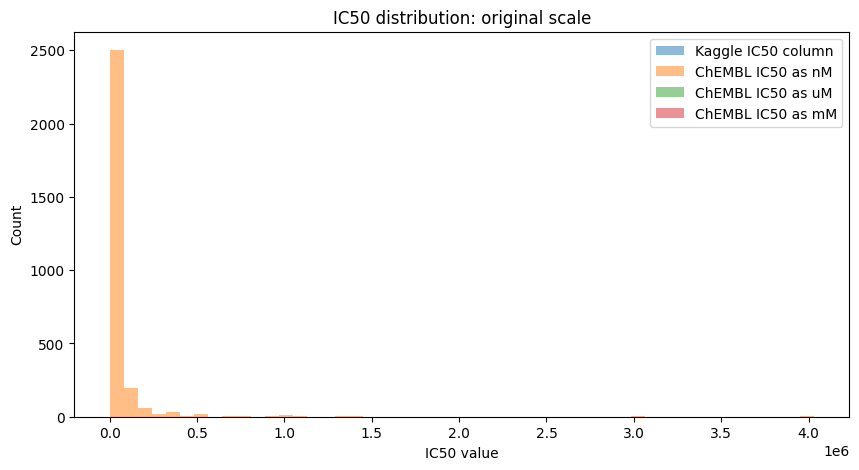

In [19]:
plt.figure(figsize=(10, 5))
plt.hist(kaggle_ic50, bins=50, alpha=0.5, label='Kaggle IC50 column')
plt.hist(chembl_nM, bins=50, alpha=0.5, label='ChEMBL IC50 as nM')
plt.hist(chembl_uM, bins=50, alpha=0.5, label='ChEMBL IC50 as uM')
plt.hist(chembl_mM, bins=50, alpha=0.5, label='ChEMBL IC50 as mM')
plt.xlabel('IC50 value')
plt.ylabel('Count')
plt.title('IC50 distribution: original scale')
plt.legend()
plt.show()

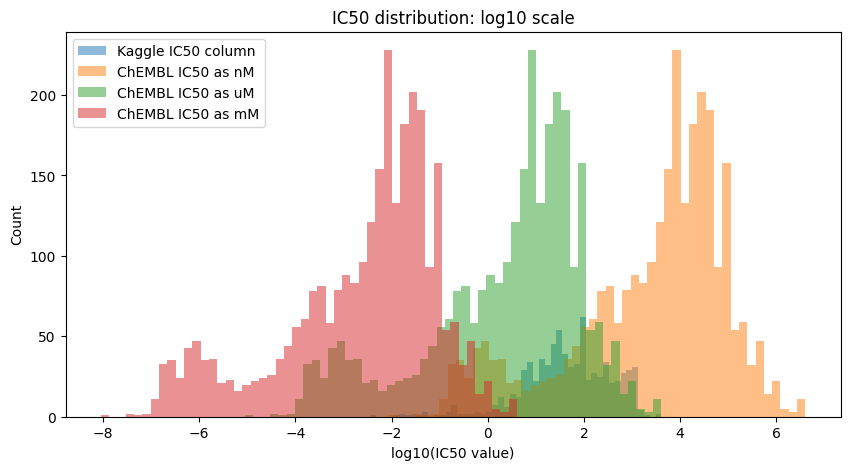

In [20]:
plt.figure(figsize=(10, 5))
plt.hist(np.log10(kaggle_ic50), bins=50, alpha=0.5, label='Kaggle IC50 column')
plt.hist(np.log10(chembl_nM), bins=50, alpha=0.5, label='ChEMBL IC50 as nM')
plt.hist(np.log10(chembl_uM), bins=50, alpha=0.5, label='ChEMBL IC50 as uM')
plt.hist(np.log10(chembl_mM), bins=50, alpha=0.5, label='ChEMBL IC50 as mM')
plt.xlabel('log10(IC50 value)')
plt.ylabel('Count')
plt.title('IC50 distribution: log10 scale')
plt.legend()
plt.show()

/var/folders/70/nzm9gbfn64vdrbrsk0c57fyw0000gn/T/ipykernel_41627/2814297059.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


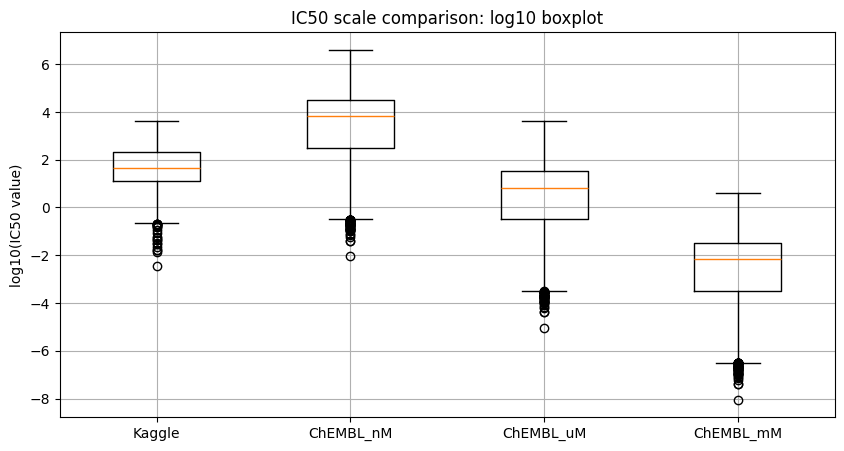

In [21]:
plot_df = pd.DataFrame({
    'Kaggle': np.log10(kaggle_ic50),
    'ChEMBL_nM': pd.Series(np.log10(chembl_nM)).reset_index(drop=True),
    'ChEMBL_uM': pd.Series(np.log10(chembl_uM)).reset_index(drop=True),
    'ChEMBL_mM': pd.Series(np.log10(chembl_mM)).reset_index(drop=True),
})

plt.figure(figsize=(10, 5))
plt.boxplot(
    [plot_df[col].dropna() for col in plot_df.columns],
    labels=plot_df.columns,
    vert=True
)
plt.ylabel('log10(IC50 value)')
plt.title('IC50 scale comparison: log10 boxplot')
plt.grid(True)
plt.show()

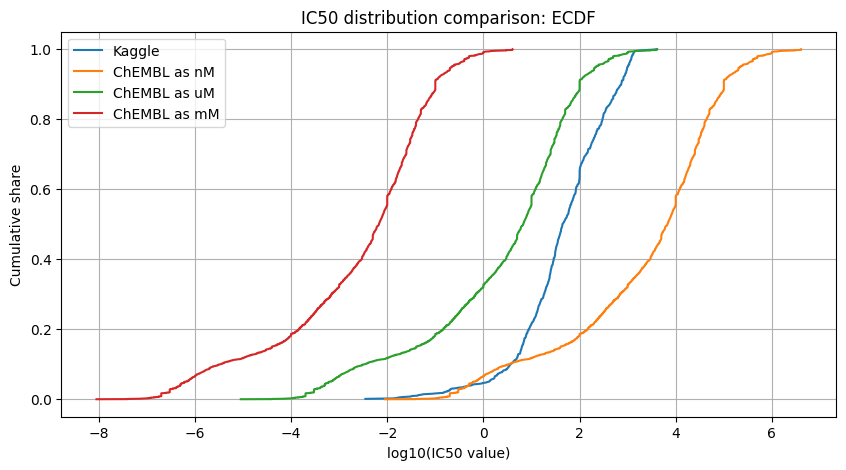

In [22]:
def plot_ecdf(values, label):
    values = np.sort(np.asarray(values))
    y = np.arange(1, len(values) + 1) / len(values)
    plt.plot(values, y, label=label)

plt.figure(figsize=(10, 5))
plot_ecdf(np.log10(kaggle_ic50), 'Kaggle')
plot_ecdf(np.log10(chembl_nM), 'ChEMBL as nM')
plot_ecdf(np.log10(chembl_uM), 'ChEMBL as uM')
plot_ecdf(np.log10(chembl_mM), 'ChEMBL as mM')
plt.xlabel('log10(IC50 value)')
plt.ylabel('Cumulative share')
plt.title('IC50 distribution comparison: ECDF')
plt.legend()
plt.grid(True)
plt.show()

## 5. RDKit-дескрипторы для ChEMBL

Считаем только те RDKit-дескрипторы, имена которых совпадают с признаками Kaggle.

In [23]:
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors.MoleculeDescriptors import MolecularDescriptorCalculator

rdkit_descriptor_names = [name for name, func in Descriptors._descList]

common_descriptor_names = [
    col for col in feature_columns
    if col in rdkit_descriptor_names
]

missing_from_rdkit = [
    col for col in feature_columns
    if col not in rdkit_descriptor_names
]

print('Kaggle features:', len(feature_columns))
print('Common RDKit descriptors:', len(common_descriptor_names))
print('Missing from RDKit calculator:', len(missing_from_rdkit))
print(missing_from_rdkit[:40])

Kaggle features: 210
Common RDKit descriptors: 210
Missing from RDKit calculator: 0
[]


In [24]:
# Считаем дескрипторы для уникальных SMILES, чтобы не пересчитывать дубли
unique_molecules = (
    chembl_ic50_long[['molecule_chembl_id', 'canonical_smiles']]
    .drop_duplicates()
    .reset_index(drop=True)
)

calculator = MolecularDescriptorCalculator(common_descriptor_names)

def calc_common_rdkit_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return pd.Series(
            [np.nan] * len(common_descriptor_names),
            index=common_descriptor_names
        )

    try:
        values = calculator.CalcDescriptors(mol)
    except Exception:
        values = [np.nan] * len(common_descriptor_names)

    return pd.Series(values, index=common_descriptor_names)

chembl_desc = unique_molecules['canonical_smiles'].apply(calc_common_rdkit_descriptors)

chembl_desc = chembl_desc.replace([np.inf, -np.inf], np.nan)

chembl_desc_long = pd.concat(
    [unique_molecules.reset_index(drop=True), chembl_desc.reset_index(drop=True)],
    axis=1
)

print(chembl_desc_long.shape)
display(chembl_desc_long.head())

(1556, 212)


,molecule_chembl_id,canonical_smiles,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,...,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,CHEMBL327097,CC(=O)Nc1ccc(C(=O)O)cc1NC(=O)CO,11.079126,11.079126,0.044128,-1.163081,0.613643,9.666667,252.226,240.130,252.074621,96.0,0.0,0.335259,-0.477638,0.477638,0.335259,1.166667,1.833333,2.333333,16.365693,10.140219,2.110202,-2.110946,2.230045,-2.178543,6.009504,-0.118494,2.297861,3.124067,498.206981,13.706742,9.558330,9.558330,8.434759,4.993794,4.993794,3.452992,3.452992,1.994914,1.994914,1.269082,1.269082,-2.41,7553.067615,13.654144,5.780813,3.562492,102.428872,20.846632,6.606882,0.000000,11.814359,0.000000,5.969305,9.589074,4.794537,0.0,0.0,0.0,...,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,CHEMBL324455,CC(=O)Nc1c(O)cc(C(=O)O)cc1[N+](=O)[O-],10.797856,10.797856,0.423611,-1.418727,0.409425,9.705882,240.171,232.107,240.038236,90.0,0.0,0.335580,-0.505468,0.505468,0.335580,1.411765,2.000000,2.411765,16.628641,10.129657,2.221140,-2.064789,2.345040,-2.091864,5.964872,-0.383547,2.187608,3.428562,510.452697,13.162772,8.629334,8.629334,7.824275,4.348918,4.348918,3.132946,3.132946,1.841401,1.841401,1.183377,1.183377,-2.64,3880.816709,12.429638,4.473433,2.680801,94.640579,15.529843,5.749512,5.687386,5.907180,5.687386,5.969305,14.908855,4.794537,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,CHEMBL321393,CC(=O)Nc1c(OC(C)=O)cc(C(=O)O)cc1[N+](=O)[O-],11.054269,11.054269,0.372500,-1.434373,0.365847,9.700000,282.208,272.128,282.048801,106.0,0.0,0.335580,-0.477635,0.477635,0.335580,1.300000,1.900000,2.300000,16.629064,10.126407,2.243621,-2.104115,2.358453,-2.128203,5.973769,-0.383536,2.284529,3.557623,609.034358,15.447229,10.498617,10.498617,9.218122,5.237683,5.237683,3.705600,3.705600,2.079721,2.079721,1.405232,1.405232,-2.97,14961.383627,15.088720,5.780026,3.510591,111.851297,15.160179,0.000000,11.436898,5.907180,5.687386,11.938611,19.703393,4.794537,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,CHEMBL109162,CC(=O)Nc1ccc(C(=O)O)cc1N,10.701189,10.701189,0.094076,-1.049931,0.610267,9.500000,194.190,184.110,194.069142,74.0,0

## 7. Molecule-level ChEMBL dataset для обучения

Для обучения делаем агрегирование по молекуле.  
Медиана нужна, чтобы молекулы с большим числом измерений не получили чрезмерный вес.

Если не агрегировать, одна молекула с 20 assays попадёт в train 20 раз и будет искусственно переважена.

In [25]:
# Выбор шкалы для обучения ChEMBL IC50.
CHEMBL_IC50_TARGET = 'IC50_uM_median'

chembl_mol = (
    chembl_ic50_long[(chembl_ic50_long['standard_value'] < 4100000)]
    .groupby(['molecule_chembl_id', 'canonical_smiles'], as_index=False)
    .agg(
        IC50_nM_median=('IC50_nM', 'median'),
        IC50_uM_median=('IC50_uM', 'median'),
        IC50_mM_median=('IC50_mM', 'median'),
        IC50_uM_mean=('IC50_uM', 'mean'),
        IC50_uM_std=('IC50_uM', 'std'),
        IC50_uM_min=('IC50_uM', 'min'),
        IC50_uM_max=('IC50_uM', 'max'),
        IC50_n_measurements=('IC50_uM', 'size'),
        n_assays=('assay_chembl_id', 'nunique')
    )
)

chembl_mol['IC50_uM_std'] = chembl_mol['IC50_uM_std'].fillna(0)

chembl_aug = chembl_mol.merge(
    chembl_desc_long,
    on=['molecule_chembl_id', 'canonical_smiles'],
    how='left'
)

print(chembl_aug.shape)
display(chembl_aug.head())
display(chembl_aug[CHEMBL_IC50_TARGET].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

(1546, 221)


,molecule_chembl_id,canonical_smiles,IC50_nM_median,IC50_uM_median,IC50_mM_median,IC50_uM_mean,IC50_uM_std,IC50_uM_min,IC50_uM_max,IC50_n_measurements,n_assays,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,...,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,CHEMBL1079175,NC1(c2ccc(-c3nc4ccn5c(=O)[nH]nc5c4cc3-c3ccccc3...,790.0,0.79,0.00079,0.79,0.0,0.79,0.79,1,1,12.022437,12.022437,0.184105,-0.259690,0.468068,15.258065,407.477,386.309,407.174610,152.0,0.0,0.347225,-0.321398,0.347225,0.321398,0.967742,1.741935,2.451613,16.148353,9.724450,2.336559,-2.382613,2.398749,-2.426650,5.976381,0.253439,3.182313,1.586198,1478.230764,21.001425,16.876763,16.876763,15.121942,10.481155,10.481155,8.308513,8.308513,6.442643,6.442643,4.476001,4.476001,-3.77,2.202130e+07,18.035310,6.617690,2.794771,177.928164,5.733667,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,CHEMBL1084041,CCCCCCCCCCCCCCCCCC(=O)N[C@@H](C)C(=O)N[C@@H](C...,4200.0,4.20,0.00420,4.20,0.0,4.20,4.20,1,1,14.612133,14.612133,0.057498,-1.631168,0.023657,15.940476,1208.672,1098.800,1207.820256,482.0,0.0,0.245420,-0.390717,0.390717,0.245420,0.559524,1.011905,1.476190,32.166368,10.004074,2.406583,-2.315997,2.219111,-2.615163,7.981029,-0.142766,4.015451,3.184645,2051.568371,63.149114,51.858804,52.675300,39.836528,30.884450,32.278297,23.159196,24.144795,14.751619,15.395569,9.910528,10.381933,-5.92,2.407918e+17,76.092807,43.666889,32.383167,504.005130,75.058537,48.334727,...,0.0,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0,0.0
2,CHEMBL1084193,CCCCCCCCCCCCCCCCCC(=O)N[C@@H](C)C(=O)N[C@@H](C...,1000000.0,1000.00,1.00000,1000.00,0.0,1000.00,1000.00,1,1,14.863122,14.863122,0.001459,-1.785182,0.018052,17.620155,1841.303,1695.143,1840.075695,726.0,0.0,0.247729,-0.393679,0.393679,0.247729,0.480620,0.945736,1.449612,32.166371,10.005211,2.447725,-2.316699,2.246886,-2.623116,7.981064,-0.143681,1.726046,1.406248,3877.757901,95.984884,76.382006,77.198503,61.223685,45.435842,46.829689,34.385330,35.370929,22.747657,23.391607,15.551847,16.023252,-10.79,3.249380e+37,110.536739,58.701942,39.599882,758.859570,121.949684,84.585772,...,0.0,0.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0,0.0
3,CHEMBL1084194,CCCCCCCCCCCCCCCCCC(=O)N[C@@H](C)C(=O)N[C@@H](C...,15000.0,

count    1546.000000
mean       72.056441
std       255.805104
min         0.000390
50%        14.500000
75%        42.950000
90%       122.750000
95%       324.750000
99%       992.215000
max      4000.000000
Name: IC50_uM_median, dtype: float64

## 9. Подготовка матриц для IC50 augmentation

In [26]:
def clean_feature_matrix(df, max_abs_value=1e12):
    df = df.copy()
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.mask(df.abs() > max_abs_value, np.nan)
    return df

def impute_and_clean(X_train_like, X_external, X_test_like, columns, max_abs_value=1e12):
    X_train_like = clean_feature_matrix(X_train_like[columns], max_abs_value=max_abs_value)
    X_external = clean_feature_matrix(X_external[columns], max_abs_value=max_abs_value)
    X_test_like = clean_feature_matrix(X_test_like[columns], max_abs_value=max_abs_value)

    imputer = SimpleImputer(strategy='median')

    X_train_imp = pd.DataFrame(
        imputer.fit_transform(X_train_like),
        columns=columns,
        index=X_train_like.index
    )

    X_external_imp = pd.DataFrame(
        imputer.transform(X_external),
        columns=columns,
        index=X_external.index
    )

    X_test_imp = pd.DataFrame(
        imputer.transform(X_test_like),
        columns=columns,
        index=X_test_like.index
    )

    # Финальная защита после imputation
    fill_values = X_train_imp.median()

    for df in [X_train_imp, X_external_imp, X_test_imp]:
        df.replace([np.inf, -np.inf], np.nan, inplace=True)
        df.mask(df.abs() > max_abs_value, np.nan, inplace=True)
        df.fillna(fill_values, inplace=True)

    return X_train_imp, X_external_imp, X_test_imp

In [27]:
X_kaggle_ic50 = train[common_descriptor_names].copy()
y_kaggle_ic50 = y_raw['IC50, mM'].copy()

X_test_common = test[common_descriptor_names].copy()

X_chembl_ic50 = chembl_aug[common_descriptor_names].copy()
y_chembl_ic50 = chembl_aug[CHEMBL_IC50_TARGET].copy()

valid_chembl_mask = (
    y_chembl_ic50.notna() &
    (y_chembl_ic50 > 0) &
    (X_chembl_ic50.isna().mean(axis=1) < 0.2)
)

X_chembl_ic50 = X_chembl_ic50[valid_chembl_mask].copy()
y_chembl_ic50 = y_chembl_ic50[valid_chembl_mask].copy()

X_kaggle_ic50_imp, X_chembl_ic50_imp, X_test_common_imp = impute_and_clean(
    X_kaggle_ic50,
    X_chembl_ic50,
    X_test_common,
    common_descriptor_names,
    max_abs_value=1e12
)

print('Kaggle IC50 train:', X_kaggle_ic50_imp.shape)
print('ChEMBL IC50 external:', X_chembl_ic50_imp.shape)
print('Test common:', X_test_common_imp.shape)

print('Kaggle finite:', np.isfinite(X_kaggle_ic50_imp.to_numpy()).all())
print('ChEMBL finite:', np.isfinite(X_chembl_ic50_imp.to_numpy()).all())
print('Test finite:', np.isfinite(X_test_common_imp.to_numpy()).all())

print('Max abs Kaggle:', np.nanmax(np.abs(X_kaggle_ic50_imp.to_numpy())))
print('Max abs ChEMBL:', np.nanmax(np.abs(X_chembl_ic50_imp.to_numpy())))
print('Max abs Test:', np.nanmax(np.abs(X_test_common_imp.to_numpy())))

Kaggle IC50 train: (751, 210)
ChEMBL IC50 external: (1546, 210)
Test common: (250, 210)
Kaggle finite: True
ChEMBL finite: True
Test finite: True
Max abs Kaggle: 648501719240.5095
Max abs ChEMBL: 915116133225.9999
Max abs Test: 335585149123.3606


## 10. Holdout sanity check: Kaggle-only vs Kaggle+ChEMBL

In [28]:
X_train_c, X_valid_c, y_train_c, y_valid_c = train_test_split(
    X_kaggle_ic50_imp,
    y_kaggle_ic50,
    test_size=0.2,
    random_state=RANDOM_STATE
)

CHEMBL_WEIGHT = 1

ic50_base_common = RandomForestRegressor(
    n_estimators=500,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

ic50_base_common.fit(X_train_c, y_train_c)
ic50_base_valid_pred = ic50_base_common.predict(X_valid_c)

X_aug_train = pd.concat(
    [X_train_c.reset_index(drop=True), X_chembl_ic50_imp.reset_index(drop=True)],
    axis=0,
    ignore_index=True
)

y_aug_train = pd.concat(
    [y_train_c.reset_index(drop=True), y_chembl_ic50.reset_index(drop=True)],
    axis=0,
    ignore_index=True
)

sample_weight_aug = np.concatenate([
    np.ones(len(X_train_c)),
    np.ones(len(X_chembl_ic50_imp)) * CHEMBL_WEIGHT
])

ic50_aug_common = RandomForestRegressor(
    n_estimators=500,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

ic50_aug_common.fit(
    X_aug_train,
    y_aug_train,
    sample_weight=sample_weight_aug
)

ic50_aug_valid_pred = ic50_aug_common.predict(X_valid_c)

print('IC50 baseline common descriptors:')
print('MAE:', mean_absolute_error(y_valid_c, ic50_base_valid_pred))
print('RMSE:', mean_squared_error(y_valid_c, ic50_base_valid_pred) ** 0.5)

print('\nIC50 augmented with ChEMBL:')
print('MAE:', mean_absolute_error(y_valid_c, ic50_aug_valid_pred))
print('RMSE:', mean_squared_error(y_valid_c, ic50_aug_valid_pred) ** 0.5)

IC50 baseline common descriptors:
MAE: 194.02741119837754
RMSE: 390.3084768226716

IC50 augmented with ChEMBL:
MAE: 192.36954539581208
RMSE: 395.34193453383574
